In [ ]:
import pandas as pd
import numpy as np
import os
import json
import re
import warnings
warnings.filterwarnings('ignore')

import spacy

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

# Sparse matrix operations
from scipy.sparse import hstack, csr_matrix


In [ ]:
# !pip install spacy
# !python -m spacy download en_core_web_sm


In [ ]:
# import torch

# # Check if GPU is available for PyTorch
# if torch.cuda.is_available():
#     print(f"CUDA is available. GPU: {torch.cuda.get_device_name(0)}")
# else:
#     print("CUDA is not available, using CPU.")

# # Enable GPU for spaCy
# spacy.require_gpu()  # returns True if a GPU is available

In [ ]:
# DATA LOADING

def load_clickbait17_data(base_path):
    print(f"\n Loading 2017 data from: {base_path}")
    instances_path = os.path.join(base_path, "instances.jsonl")
    truth_path = os.path.join(base_path, "truth.jsonl")
    instances = pd.read_json(instances_path, lines=True)
    truth = pd.read_json(truth_path, lines=True)
    df = instances.merge(truth, on="id")
    df['headline'] = df['postText'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else str(x)
    )
    df['label'] = (df['truthMean'] >= 0.5).astype(int)
    df = df[['headline', 'label']].dropna().copy()
    print(f"Loaded {len(df)} samples")
    print(f"  - Clickbait: {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
    print(f"  - Non-clickbait: {(1 - df['label']).sum()} ({(1 - df['label'].mean())*100:.1f}%)")
    return df


def load_clickbait17_test(base_path):
    print(f"\n Loading 2017 TEST data from: {base_path}")
    instances_path = os.path.join(base_path, "instances.jsonl")
    truth_path = os.path.join(base_path, "truth.jsonl")
    instances = pd.read_json(instances_path, lines=True)
    truth = pd.read_json(truth_path, lines=True)
    df = instances.merge(truth, on="id")
    df['headline'] = df['postText'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else str(x)
    )
    df['label'] = (df['truthMean'] >= 0.5).astype(int)
    df = df[['headline', 'label']].dropna().copy()
    print(f" Loaded {len(df)} test samples")
    print(f"  - Clickbait: {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
    print(f"  - Non-clickbait: {(1 - df['label']).sum()} ({(1 - df['label'].mean())*100:.1f}%)")
    return df


def load_webis16_data(base_path):
    print(f"\nLoading 2016 data from: {base_path}")
    problems_path = os.path.join(base_path, "problems")
    truth_file = os.path.join(base_path, "truth", "majority.csv")
    truth_df = pd.read_csv(truth_file, header=None, dtype={0: str})
    truth_df.columns = ["id", "label_str"]
    truth_map = dict(zip(truth_df["id"], truth_df["label_str"]))
    data = []
    for folder in sorted(os.listdir(problems_path)):
        folder_path = os.path.join(problems_path, folder)
        if not os.path.isdir(folder_path):
            continue
        label_str = truth_map.get(folder)
        if label_str is None:
            continue
        label = 1 if label_str == "clickbait" else 0
        for f in os.listdir(folder_path):
            if f.endswith(".json"):
                json_path = os.path.join(folder_path, f)
                try:
                    with open(json_path, "r", encoding="utf-8") as file:
                        problem = json.load(file)
                except:
                    continue
                headline = None
                if "postText" in problem:
                    val = problem["postText"]
                    headline = val[0] if isinstance(val, list) and len(val) > 0 else val
                elif "text" in problem:
                    headline = problem["text"]
                elif "title" in problem:
                    headline = problem["title"]
                if headline and isinstance(headline, str):
                    data.append([headline, label])
                break
    df = pd.DataFrame(data, columns=["headline", "label"]).dropna()
    print(f"Loaded {len(df)} samples")
    print(f"  - Clickbait: {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
    print(f"  - Non-clickbait: {(1 - df['label']).sum()} ({(1 - df['label'].mean())*100:.1f}%)")
    return df


In [ ]:
# LOAD ALL DATASETS

print("LOADING ALL DATASETS")

BASE_PATH = "/kaggle/input/datasets/abhijit027"

PATH_2017_SMALL = os.path.join(BASE_PATH, "clickbait-2017-train", "clickbait17-train-170331", "clickbait17-train-170331")
PATH_2017_LARGE = os.path.join(BASE_PATH, "clickbait-2017-train", "clickbait17-train-170630", "clickbait17-validation-170630")
PATH_2017_TEST  = os.path.join(BASE_PATH, "clickbait-2017-test",  "clickbait17-test-170720")
PATH_2016       = os.path.join(BASE_PATH, "clickbait-2016",       "webis-clickbait-16")

print("1. Loading 2017 SMALL dataset")
df_2017_small = load_clickbait17_data(PATH_2017_SMALL)

print("\n2. Loading 2017 LARGE dataset")
df_2017_large = load_clickbait17_data(PATH_2017_LARGE)

print("\n3. Loading 2017 TEST dataset (WITH LABELS)")
df_2017_test = load_clickbait17_test(PATH_2017_TEST)

print("\n4. Loading 2016 dataset")
df_2016 = load_webis16_data(PATH_2016)

print("\nCombining 2017 SMALL + LARGE datasets")
df_train_full = pd.concat([df_2017_large, df_2017_small], ignore_index=True)
df_train_full = df_train_full.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Combined Training Samples: {len(df_train_full)}")
print("\nDATASET SUMMARY")
print(f"2017 Combined Training: {len(df_train_full)} samples")
print(f"2017 Test:              {len(df_2017_test)} samples")
print(f"2016 Test:              {len(df_2016)} samples")


LOADING ALL DATASETS
1. Loading 2017 SMALL dataset

 Loading 2017 data from: /kaggle/input/datasets/abhijit027/clickbait-2017-train/clickbait17-train-170331/clickbait17-train-170331
Loaded 2459 samples
  - Clickbait: 710 (28.9%)
  - Non-clickbait: 1749 (71.1%)

2. Loading 2017 LARGE dataset

 Loading 2017 data from: /kaggle/input/datasets/abhijit027/clickbait-2017-train/clickbait17-train-170630/clickbait17-validation-170630
Loaded 19538 samples
  - Clickbait: 4740 (24.3%)
  - Non-clickbait: 14798 (75.7%)

3. Loading 2017 TEST dataset (WITH LABELS)

 Loading 2017 TEST data from: /kaggle/input/datasets/abhijit027/clickbait-2017-test/clickbait17-test-170720
 Loaded 18979 test samples
  - Clickbait: 4404 (23.2%)
  - Non-clickbait: 14575 (76.8%)

4. Loading 2016 dataset

Loading 2016 data from: /kaggle/input/datasets/abhijit027/clickbait-2016/webis-clickbait-16
Loaded 2992 samples
  - Clickbait: 767 (25.6%)
  - Non-clickbait: 2225 (74.4%)

Combining 2017 SMALL + LARGE datasets
Combined Trai

# Syntactic Features Model

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(
#     df_2017['headline'],
#     df_2017['label'],
#     test_size=0.2,
#     random_state=42,
#     stratify=df_2017['label']
# )

In [ ]:
# Training data
X_train = df_train_full['headline']
y_train = df_train_full['label']

# Test data (2017 test set)
X_test = df_2017_test['headline']
y_test = df_2017_test['label']

# Cross-dataset test (2016)
X_2016 = df_2016['headline']
y_2016 = df_2016['label']


In [ ]:
# !python -m spacy download en_core_web_sm

In [ ]:
nlp = spacy.load("en_core_web_sm", disable=["ner"])

In [ ]:
def extract_syntactic_features(texts):
    rows = []

    for doc in nlp.pipe(texts, batch_size=128):

        pos_tags = [token.pos_ for token in doc]
        dep_tags = [token.dep_ for token in doc]

        # POS counts
        pos_counts = {f"pos_{tag}": pos_tags.count(tag) for tag in set(pos_tags)}

        # Dependency + head POS (IMPORTANT improvement)
        dep_patterns = [f"{token.dep_}->{token.head.pos_}" for token in doc]
        dep_counts = {f"dep_{d}": dep_patterns.count(d) for d in set(dep_patterns)}

        num_tokens = len(doc)

        row = {
            **pos_counts,
            **dep_counts,
            "num_tokens": num_tokens,
            # "verb_ratio": pos_tags.count("VERB") / num_tokens if num_tokens > 0 else 0,
            # "noun_ratio": pos_tags.count("NOUN") / num_tokens if num_tokens > 0 else 0,
            # "adj_ratio": pos_tags.count("ADJ") / num_tokens if num_tokens > 0 else 0,
            # "adv_ratio": pos_tags.count("ADV") / num_tokens if num_tokens > 0 else 0,
            "is_question": int(any(token.text == "?" for token in doc)),
            "num_exclam": doc.text.count("!"),
            "starts_with_pronoun": int(len(doc) > 0 and doc[0].pos_ == "PRON"),
            "avg_token_len": np.mean([len(token.text) for token in doc]) if num_tokens > 0 else 0
        }

        rows.append(row)

    df = pd.DataFrame(rows).fillna(0)
    return df

In [ ]:
X_train_syn = extract_syntactic_features(X_train)
X_test_syn  = extract_syntactic_features(X_test)
X_2016_syn  = extract_syntactic_features(X_2016)

# Align test sets to training columns (fill missing with 0)
X_test_syn  = X_test_syn.reindex(columns=X_train_syn.columns, fill_value=0)
X_2016_syn  = X_2016_syn.reindex(columns=X_train_syn.columns, fill_value=0)


In [ ]:
X_train_syn.head()

,pos_NOUN,pos_DET,pos_PART,pos_CCONJ,pos_PUNCT,pos_ADP,pos_ADJ,pos_VERB,pos_NUM,pos_PRON,...,dep_amod->CCONJ,dep_amod->AUX,dep_nsubjpass->NOUN,dep_prt->NUM,dep_meta->X,dep_meta->AUX,dep_csubj->PUNCT,dep_prt->AUX,dep_conj->INTJ,dep_acomp->PUNCT
0,3.0,1.0,1.0,2.0,3.0,1.0,4.0,4.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,3.0,0.0,1.0,2.0,1.0,0.0,3.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_syn)
X_test_scaled  = scaler.transform(X_test_syn)
X_2016_scaled  = scaler.transform(X_2016_syn)


## SVM

In [ ]:
model = LinearSVC()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [ ]:
print("2017 TEST RESULTS")
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

2017 TEST RESULTS
SVM Accuracy: 0.8448284946519837
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     14575
           1       0.70      0.57      0.63      4404

    accuracy                           0.84     18979
   macro avg       0.79      0.75      0.77     18979
weighted avg       0.84      0.84      0.84     18979



In [ ]:
# model = LinearSVC()
model = LinearSVC(class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [ ]:
print("2017 TEST RESULTS")
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

2017 TEST RESULTS
SVM Accuracy: 0.7852363138205385
              precision    recall  f1-score   support

           0       0.93      0.78      0.85     14575
           1       0.52      0.82      0.64      4404

    accuracy                           0.79     18979
   macro avg       0.73      0.80      0.74     18979
weighted avg       0.84      0.79      0.80     18979



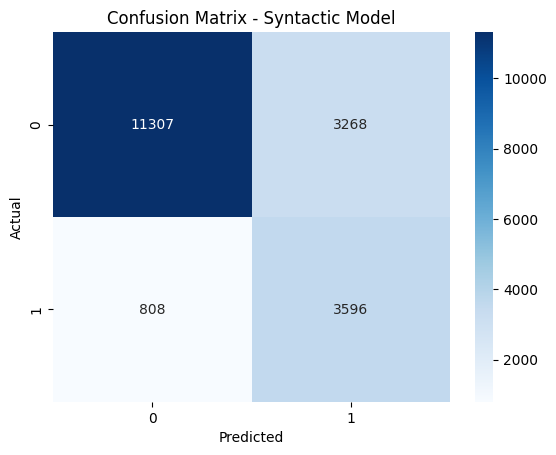

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Syntactic Model")
plt.show()

In [ ]:
results = pd.DataFrame({
    "headline": X_test.values,
    "true": y_test.values,
    "pred": y_pred
})

False positives

In [ ]:
results[(results.true == 0) & (results.pred == 1)].head(3)

,headline,true,pred
4,It's not enough to let employees work flexible...,0,1
5,"Out of 15 lakh registered companies in India, ...",0,1
8,President Donald Trump: My first 100 days are ...,0,1


False negatives

In [ ]:
results[(results.true == 1) & (results.pred == 0)].head(3)

,headline,true,pred
23,still learning cause &amp; effect over there,1,0
32,Jealous wife chops off her husband's PENIS wit...,1,0
51,Latest Uber controversy sheds light on how com...,1,0


## Logistic Regression

In [ ]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)
print("2017 TEST RESULTS")
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

2017 TEST RESULTS
LR Accuracy: 0.8453553928025712
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     14575
           1       0.70      0.59      0.64      4404

    accuracy                           0.85     18979
   macro avg       0.79      0.76      0.77     18979
weighted avg       0.84      0.85      0.84     18979



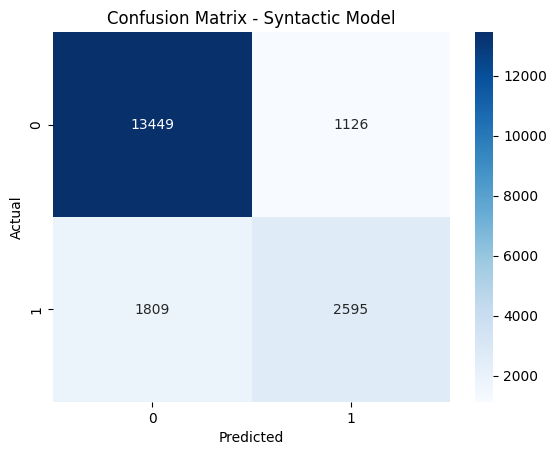

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Syntactic Model")
plt.show()

In [ ]:
model_lr = LogisticRegression(class_weight='balanced',max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)
print("2017 TEST RESULTS")
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

2017 TEST RESULTS
LR Accuracy: 0.7837609989988935
              precision    recall  f1-score   support

           0       0.93      0.77      0.85     14575
           1       0.52      0.82      0.64      4404

    accuracy                           0.78     18979
   macro avg       0.73      0.80      0.74     18979
weighted avg       0.84      0.78      0.80     18979



## Cross-dataset test

In [ ]:
y_pred_2016 = model.predict(X_2016_scaled)

print("\n2016 CROSS-DATASET RESULTS")
print("Accuracy:", accuracy_score(y_2016, y_pred_2016))
print(classification_report(y_2016, y_pred_2016))


2016 CROSS-DATASET RESULTS
Accuracy: 0.7780748663101604
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      2225
           1       0.61      0.37      0.46       767

    accuracy                           0.78      2992
   macro avg       0.71      0.64      0.66      2992
weighted avg       0.76      0.78      0.76      2992



# POS sequence +TFIDF

In [ ]:
def pos_sequence(texts):
    return [" ".join([token.pos_ for token in doc])
            for doc in nlp.pipe(texts, batch_size=128, n_process = 2)]

In [ ]:
pos_train = pos_sequence(X_train)
pos_test = pos_sequence(X_test)
pos_2016 = pos_sequence(X_2016)

vectorizer = TfidfVectorizer(ngram_range=(2,3), min_df=3)

X_train_pos = vectorizer.fit_transform(pos_train)
X_test_pos = vectorizer.transform(pos_test)
X_2016_pos = vectorizer.transform(pos_2016)

print("POS TF-IDF shape:", X_train_pos.shape)

POS TF-IDF shape: (21997, 2535)


In [ ]:
pos_train[1:5]

['PUNCT',
 'DET NOUN VERB NOUN ADP DET PROPN PUNCT PROPN PUNCT VERB DET NOUN NOUN CCONJ ADV VERB PRON',
 'PRON AUX PRON NOUN VERB PART VERB NOUN PUNCT SYM NOUN',
 'ADJ NOUN PUNCT ADV INTJ NOUN SPACE SYM NOUN']

In [ ]:
# model_pos = LinearSVC()
model_pos = LinearSVC(class_weight='balanced')
model_pos.fit(X_train_pos, y_train)

y_pred_pos = model_pos.predict(X_test_pos)

print("2017 TEST RESULTS")
print("POS-TFIDF Accuracy:", accuracy_score(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

2017 TEST RESULTS
POS-TFIDF Accuracy: 0.7938247536751146
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     14575
           1       0.54      0.78      0.64      4404

    accuracy                           0.79     18979
   macro avg       0.73      0.79      0.75     18979
weighted avg       0.83      0.79      0.81     18979



In [ ]:
# Logistic Regression model
model_pos_lr = LogisticRegression(max_iter=1000, class_weight='balanced')

model_pos_lr.fit(X_train_pos, y_train)

y_pred_pos_lr = model_pos_lr.predict(X_test_pos)

print("2017 TEST RESULTS (Logistic Regression)")
print("POS-TFIDF Accuracy:", accuracy_score(y_test, y_pred_pos_lr))
print(classification_report(y_test, y_pred_pos_lr))

2017 TEST RESULTS (Logistic Regression)
POS-TFIDF Accuracy: 0.7871331471626535
              precision    recall  f1-score   support

           0       0.93      0.78      0.85     14575
           1       0.53      0.80      0.64      4404

    accuracy                           0.79     18979
   macro avg       0.73      0.79      0.74     18979
weighted avg       0.84      0.79      0.80     18979



In [ ]:
y_pred_2016 = model_pos.predict(X_2016_pos)

print("\n2016 CROSS-DATASET RESULTS")
print("Accuracy:", accuracy_score(y_2016, y_pred_2016))
print(classification_report(y_2016, y_pred_2016))


2016 CROSS-DATASET RESULTS
Accuracy: 0.7934491978609626
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      2225
           1       0.61      0.53      0.57       767

    accuracy                           0.79      2992
   macro avg       0.73      0.71      0.72      2992
weighted avg       0.79      0.79      0.79      2992



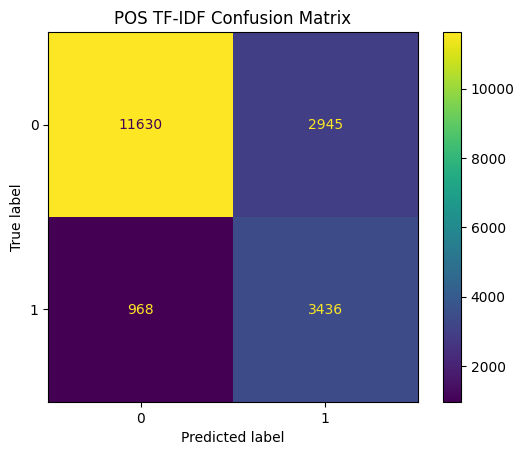

In [ ]:
cm = confusion_matrix(y_test, y_pred_pos)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("POS TF-IDF Confusion Matrix")
plt.show()

In [ ]:
pos_train = pos_sequence(X_train)
pos_test = pos_sequence(X_test)
pos_2016 = pos_sequence(X_2016)

vectorizer = TfidfVectorizer(ngram_range=(2,3), min_df=2)

X_train_pos = vectorizer.fit_transform(pos_train)
X_test_pos = vectorizer.transform(pos_test)
X_2016_pos = vectorizer.transform(pos_2016)

print("POS TF-IDF shape:", X_train_pos.shape)

POS TF-IDF shape: (21997, 2799)


In [ ]:
pos_train[1:5]

['PUNCT',
 'DET NOUN VERB NOUN ADP DET PROPN PUNCT PROPN PUNCT VERB DET NOUN NOUN CCONJ ADV VERB PRON',
 'PRON AUX PRON NOUN VERB PART VERB NOUN PUNCT SYM NOUN',
 'ADJ NOUN PUNCT ADV INTJ NOUN SPACE SYM NOUN']

In [ ]:
# model_pos = LinearSVC()
model_pos = LinearSVC(class_weight='balanced')
model_pos.fit(X_train_pos, y_train)

y_pred_pos = model_pos.predict(X_test_pos)

print("2017 TEST RESULTS")
print("POS-TFIDF Accuracy:", accuracy_score(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

2017 TEST RESULTS
POS-TFIDF Accuracy: 0.7937720638600558
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     14575
           1       0.54      0.78      0.64      4404

    accuracy                           0.79     18979
   macro avg       0.73      0.79      0.75     18979
weighted avg       0.83      0.79      0.81     18979



In [ ]:
y_pred_2016 = model_pos.predict(X_2016_pos)

print("\n2016 CROSS-DATASET RESULTS")
print("Accuracy:", accuracy_score(y_2016, y_pred_2016))
print(classification_report(y_2016, y_pred_2016))


2016 CROSS-DATASET RESULTS
Accuracy: 0.7937834224598931
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      2225
           1       0.61      0.53      0.57       767

    accuracy                           0.79      2992
   macro avg       0.73      0.71      0.72      2992
weighted avg       0.79      0.79      0.79      2992



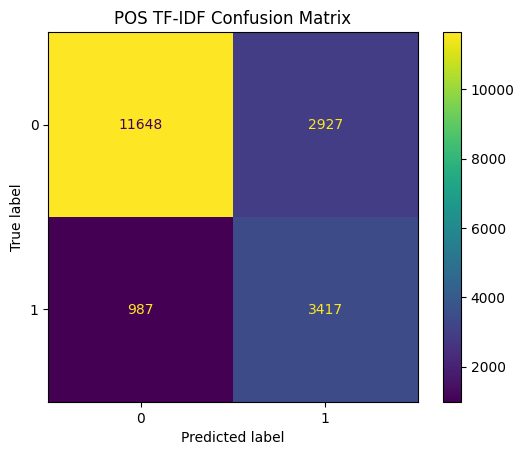

In [ ]:
cm = confusion_matrix(y_test, y_pred_pos)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("POS TF-IDF Confusion Matrix")
plt.show()

In [ ]:
# results_pos = pd.DataFrame({
#     "headline": X_test.values,
#     "true": y_test.values,
#     "pred": y_pred_pos
# })

# print("False Positives:")
# print(results_pos[(results_pos.true == 0) & (results_pos.pred == 1)].head(3))

# print("\nFalse Negatives:")
# print(results_pos[(results_pos.true == 1) & (results_pos.pred == 0)].head(3))

# Combined Model (pos seq + dependencies)

In [ ]:
# # Convert syntactic DataFrame → numpy
# X_train_syn_np = X_train_scaled
# X_test_syn_np = X_test_scaled

# # Combine TF-IDF + syntactic
# X_train_combined = hstack([X_train_pos, X_train_syn_np])
# X_test_combined = hstack([X_test_pos, X_test_syn_np])

# print("Combined shape:", X_train_combined.shape)

In [ ]:
X_train_syn_sparse = csr_matrix(X_train_scaled)
X_test_syn_sparse  = csr_matrix(X_test_scaled)
X_2016_syn_sparse  = csr_matrix(X_2016_scaled)

# Combine POS TF-IDF + syntactic features
X_train_combined = hstack([X_train_pos, X_train_syn_sparse])
X_test_combined  = hstack([X_test_pos,  X_test_syn_sparse])
X_2016_combined  = hstack([X_2016_pos,  X_2016_syn_sparse])

print("Combined shape:", X_train_combined.shape)


Combined shape: (21997, 2976)


In [ ]:
# model_comb = LinearSVC(max_iter=5000)
model_comb = LinearSVC(max_iter=5000, class_weight='balanced')
model_comb.fit(X_train_combined, y_train)

y_pred_comb = model_comb.predict(X_test_combined)

print("Combined Model Accuracy:", accuracy_score(y_test, y_pred_comb))
print(classification_report(y_test, y_pred_comb))

Combined Model Accuracy: 0.7988829759207545
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     14575
           1       0.55      0.79      0.65      4404

    accuracy                           0.80     18979
   macro avg       0.74      0.80      0.75     18979
weighted avg       0.84      0.80      0.81     18979



In [ ]:
y_pred_2016 = model_comb.predict(X_2016_combined)

print("\n2016 CROSS-DATASET RESULTS")
print("Accuracy:", accuracy_score(y_2016, y_pred_2016))
print(classification_report(y_2016, y_pred_2016))


2016 CROSS-DATASET RESULTS
Accuracy: 0.7857620320855615
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      2225
           1       0.61      0.45      0.52       767

    accuracy                           0.79      2992
   macro avg       0.72      0.68      0.69      2992
weighted avg       0.77      0.79      0.77      2992



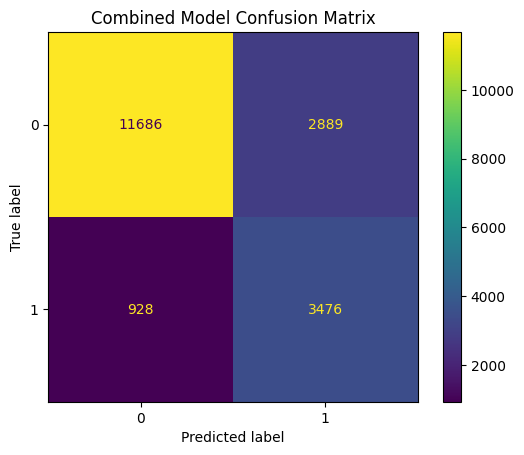

In [ ]:
cm = confusion_matrix(y_test, y_pred_comb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Combined Model Confusion Matrix")
plt.show()

In [ ]:
# model_comb_lr = LogisticRegression(max_iter=1000, class_weight='balanced')

# model_comb_lr.fit(X_train_combined, y_train)

# y_pred_comb_lr = model_comb_lr.predict(X_test_combined)

# print("Combined Model Accuracy:", accuracy_score(y_test, y_pred_comb_lr))
# print(classification_report(y_test, y_pred_comb_lr))

Combined Model Accuracy: 0.7996733231466358
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     14575
           1       0.55      0.82      0.66      4404

    accuracy                           0.80     18979
   macro avg       0.74      0.81      0.76     18979
weighted avg       0.85      0.80      0.81     18979



Combined Model Accuracy: 0.7996733231466358
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     14575
           1       0.55      0.82      0.66      4404

    accuracy                           0.80     18979
   macro avg       0.74      0.81      0.76     18979
weighted avg       0.85      0.80      0.81     18979



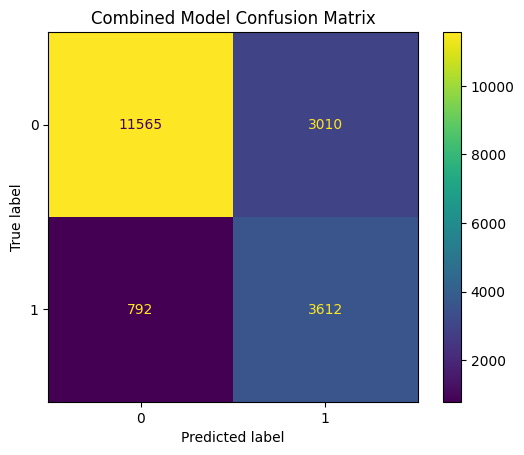

In [ ]:
# y_pred_comb_lr = model_comb_lr.predict(X_test_combined)

# print("Combined Model Accuracy:", accuracy_score(y_test, y_pred_comb_lr))
# print(classification_report(y_test, y_pred_comb_lr))
# cm = confusion_matrix(y_test, y_pred_comb_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()
# plt.title("Combined Model Confusion Matrix")
# plt.show()

In [ ]:
# y_proba = model_comb_lr.predict_proba(X_test_combined)[:, 1]

# y_pred_comb_lr = (y_proba > 0.75).astype(int)
# print("Combined Model Accuracy:", accuracy_score(y_test, y_pred_comb_lr))
# print(classification_report(y_test, y_pred_comb_lr))

Combined Model Accuracy: 0.846461878918805
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     14575
           1       0.70      0.60      0.64      4404

    accuracy                           0.85     18979
   macro avg       0.79      0.76      0.77     18979
weighted avg       0.84      0.85      0.84     18979



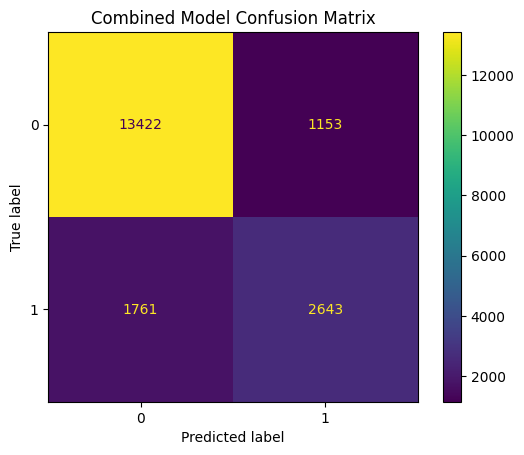

In [ ]:
# cm = confusion_matrix(y_test, y_pred_comb_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()
# plt.title("Combined Model Confusion Matrix")
# plt.show()

In [ ]:
print("start")
param_grid = {
    'C': [0.01, 0.1, 1],
    'loss': ['hinge', 'squared_hinge'],
    'max_iter': [5000],
    'dual': [False]
}

grid = GridSearchCV(
    LinearSVC(class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=1
)

grid.fit(X_train_combined, y_train)

print("Best Parameters:", grid.best_params_)

best_model_comb = grid.best_estimator_

y_pred_comb = best_model_comb.predict(X_test_combined)

print("Combined Model Accuracy:", accuracy_score(y_test, y_pred_comb))
print(classification_report(y_test, y_pred_comb))

start
Best Parameters: {'C': 0.1, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 5000}
Combined Model Accuracy: 0.8016228463038094
              precision    recall  f1-score   support

           0       0.94      0.80      0.86     14575
           1       0.55      0.82      0.66      4404

    accuracy                           0.80     18979
   macro avg       0.74      0.81      0.76     18979
weighted avg       0.85      0.80      0.81     18979



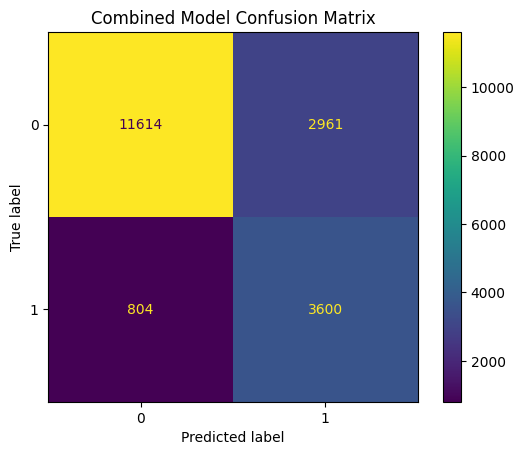

In [ ]:
cm = confusion_matrix(y_test, y_pred_comb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Combined Model Confusion Matrix")
plt.show()

In [ ]:
results_comb = pd.DataFrame({
    "headline": X_test.values,
    "true": y_test.values,
    "pred": y_pred_comb
})

print("False Positives:")
print(results_comb[(results_comb.true == 0) & (results_comb.pred == 1)].head(3))

print("\nFalse Negatives:")
print(results_comb[(results_comb.true == 1) & (results_comb.pred == 0)].head(3))

False Positives:
                                             headline  true  pred
4   It's not enough to let employees work flexible...     0     1
5   Out of 15 lakh registered companies in India, ...     0     1
10  Don't abandon the snot if you want to be healt...     0     1

False Negatives:
                                              headline  true  pred
23        still learning cause &amp; effect over there     1     0
76   Cheeky marathon runner soaks the future king o...     1     0
116  Chris Brown's new documentary is coming to the...     1     0


In [ ]:
feature_names = list(vectorizer.get_feature_names_out()) + list(X_train_syn.columns)

coef = model_comb.coef_[0]

top_features = sorted(zip(coef, feature_names), reverse=True)[:20]

print("Top Positive Features (Clickbait Indicators):\n")
for val, feat in top_features:
    print(feat, val)

Top Positive Features (Clickbait Indicators):

pron adv noun 1.9997781197051219
cconj aux noun 1.833296122390556
num noun 1.7329456080042418
space verb adp 1.706460405348697
aux adv adj 1.6287937604587799
verb num aux 1.5625491202582564
adv punct part 1.5380561239587092
num noun det 1.5345280471357976
propn verb cconj 1.5067069292454478
num adp sym 1.475730365761002
adj propn pron 1.4741543795959184
aux punct propn 1.470836260185142
part noun space 1.4664111395304156
num propn cconj 1.4553337721585378
det adj 1.4487438220458724
adv punct num 1.4341261457608279
cconj adp num 1.4336347602385964
num adj propn 1.416789074488445
adp punct cconj 1.4051420646630037
det noun 1.4022293310939185


In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

grid = GridSearchCV(
    LogisticRegression(class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_combined, y_train)

print("Best Parameters:", grid.best_params_)

best_model_comb = grid.best_estimator_

y_pred_comb = best_model_comb.predict(X_test_combined)

print("Combined Model Accuracy:", accuracy_score(y_test, y_pred_comb))
print(classification_report(y_test, y_pred_comb))

Best Parameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Combined Model Accuracy: 0.800463670372517
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     14575
           1       0.55      0.82      0.66      4404

    accuracy                           0.80     18979
   macro avg       0.74      0.81      0.76     18979
weighted avg       0.85      0.80      0.81     18979

